Lower constraint z_alpha: -1.64485363
Numerical minimizer z*:   1.44053689
Corresponding Phi(z*):    0.92514222
Minimum F(z*):            -0.24401017


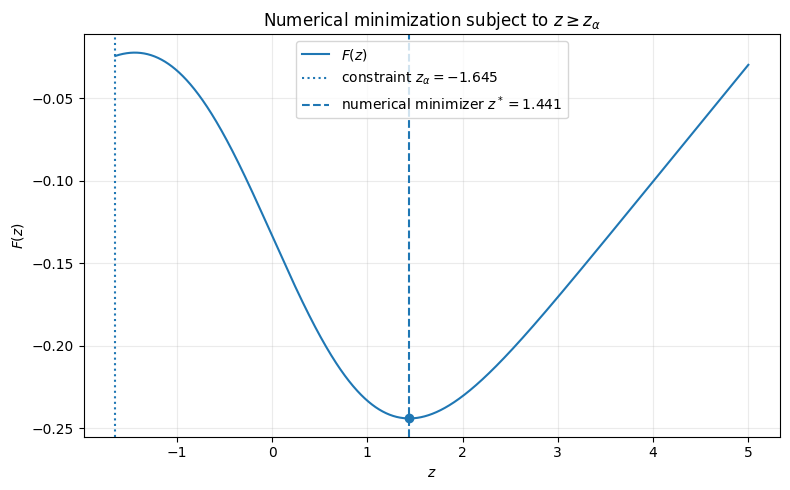

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import norm


def F(z, lam, psi, theta, N, alpha):
    """Evaluate F(z)."""
    z_1_minus_alpha = norm.ppf(1 - alpha)

    return (
        -lam * (1 - psi)
        + (
            lam * np.sqrt(1 - psi)
            / (theta * np.sqrt(N))
            * (z_1_minus_alpha + z)
        )
        + (1 - lam) * (1 - norm.cdf(z))
    )


def find_minimizer(
    lam,
    psi,
    theta,
    N,
    alpha,
    initial_upper=5.0,
    expansion_factor=2.0,
    max_upper=100.0,
):
    """
    Numerically minimize F(z) subject to z >= z_alpha.

    The upper endpoint is expanded until the optimizer is safely
    inside the numerical search interval.
    """
    z_lower = norm.ppf(alpha)
    z_upper = max(initial_upper, z_lower + 1.0)

    while True:
        result = minimize_scalar(
            lambda z: F(z, lam, psi, theta, N, alpha),
            bounds=(z_lower, z_upper),
            method="bounded",
            options={
                "xatol": 1e-12,
                "maxiter": 10_000,
            },
        )

        if not result.success:
            raise RuntimeError(f"Optimization failed: {result.message}")

        # Accept once the solution is not close to the upper boundary.
        tolerance = 1e-4 * max(1.0, abs(z_upper - z_lower))
        if result.x < z_upper - tolerance:
            break

        z_upper *= expansion_factor

        if z_upper > max_upper:
            raise RuntimeError(
                "Could not find a sufficiently large upper search bound."
            )

    return {
        "z_alpha": z_lower,
        "z_star": result.x,
        "b_star": norm.cdf(result.x),
        "F_star": result.fun,
        "optimization_result": result,
    }


# Parameters
lam = 0.50
psi = 0.001
theta = 0.1
N = 5000
alpha = 0.05

solution = find_minimizer(
    lam=lam,
    psi=psi,
    theta=theta,
    N=N,
    alpha=alpha,
)

z_alpha = solution["z_alpha"]
z_star = solution["z_star"]
b_star = solution["b_star"]
F_star = solution["F_star"]

print(f"Lower constraint z_alpha: {z_alpha:.8f}")
print(f"Numerical minimizer z*:   {z_star:.8f}")
print(f"Corresponding Phi(z*):    {b_star:.8f}")
print(f"Minimum F(z*):            {F_star:.8f}")


# Plot over the feasible region
z_plot_upper = max(5.0, z_star + 2.0)
z_grid = np.linspace(z_alpha, z_plot_upper, 2000)
F_grid = F(z_grid, lam, psi, theta, N, alpha)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(z_grid, F_grid, label=r"$F(z)$")
ax.axvline(
    z_alpha,
    linestyle=":",
    label=rf"constraint $z_\alpha={z_alpha:.3f}$",
)
ax.axvline(
    z_star,
    linestyle="--",
    label=rf"numerical minimizer $z^*={z_star:.3f}$",
)
ax.scatter([z_star], [F_star], zorder=3)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$F(z)$")
ax.set_title(r"Numerical minimization subject to $z\geq z_\alpha$")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [11]:
np.sqrt(2 * np.log(theta * np.sqrt(N) / np.sqrt(2 * np.pi * (1 - psi))))

np.float64(1.4405368580332765)